### Phase 2: A/B Testing Statistical Analysis
Evaluating the conversion rate difference between the Ad and PSA groups using Frequentist and Bayesian methodologies.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import matplotlib.ticker as mtick

sns.set_theme(style="whitegrid")
%matplotlib inline

In [2]:
# Load data
df = pd.read_csv("../data/marketing_data.csv" , index_col=0)

# Display first rows
df.head()

,user id,test group,converted,total ads,most ads day,most ads hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14


In [3]:
# Calculate summary metrics
summary = df.groupby('test group').agg(
    users=('user id', 'count'),
    conversions=('converted', 'sum')
)
summary['conversion_rate (%)'] = (summary['conversions'] / summary['users']) * 100
display(summary)

,users,conversions,conversion_rate (%)
test group,,,
ad,564577,14423,2.554656
psa,23524,420,1.785411


#### 2.0 Pre-Test Check: Power Analysis
Before analyzing the results, we must confirm our test was "adequately powered." If our sample size is too small, we risk a False Negative (Type II error) — failing to detect that the Ad campaign was better.

We will calculate the **Achieved Power** of our test based on the actual sample sizes and the observed effect size (Cohen's $h$) between the two groups.
* **Target Power:** 80% (0.80)
* **Significance ($\alpha$):** 5% (0.05)

In [ ]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Extract parameters from our summary table
cr_ad = summary.loc['ad', 'conversion_rate (%)'] / 100
cr_psa = summary.loc['psa', 'conversion_rate (%)'] / 100

n_ad = summary.loc['ad', 'users']
n_psa = summary.loc['psa', 'users']

# Calculate Effect Size (Cohen's h for proportions)
effect_size = proportion_effectsize(cr_ad, cr_psa)

# Calculate Achieved Power
analysis = NormalIndPower()

achieved_power = analysis.solve_power(
    effect_size=effect_size,
    alpha=0.05,
    nobs1=n_psa,
    ratio=n_ad / n_psa
)

print(f"Observed Effect Size (Cohen's h): {abs(effect_size):.4f}")
print(f"PSA Group Size (n): {n_psa:,}")
print(f"Ad Group Size (n): {n_ad:,}")
print(f"Target Power: 80.00%")
print(f"Achieved Power: {achieved_power * 100:.2f}%\n")

if achieved_power >= 0.80:
    print("Result: The test is adequately powered. We can trust the statistical results.")
else:
    print("Warning: The test is underpowered. We need more users in the PSA group.")

Observed Effect Size (Cohen's h): 0.0530
PSA Group Size (n): 23,524
Ad Group Size (n): 564,577
Target Power: 80.00%
Achieved Power: 100.00%

Result: The test is adequately powered. We can trust the statistical results.


#### 2.1 Frequentist Approach: Chi-Squared Test
Testing if the observed difference in conversion rates is statistically significant.
* **H0:** Conversion rates are equal.
* **HA:** Conversion rates are different.
* **Alpha ($\alpha$):** 0.05

In [5]:
# Create contingency table
contingency_table = pd.crosstab(df['test group'], df['converted'])
display(contingency_table)

# Run Chi-Squared Test
chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi-Squared Statistic: {chi2_stat:.4f}")
print(f"P-value: {p_value:.4e}")

if p_value < 0.05:
    print("Result: Reject H0. The difference is statistically significant.")
else:
    print("Result: Fail to reject H0. No significant difference.")

converted,False,True
test group,,
ad,550154,14423
psa,23104,420


Chi-Squared Statistic: 54.0058
P-value: 1.9990e-13
Result: Reject H0. The difference is statistically significant.


#### 2.2 Frequentist Approach: Welch t-Test & Confidence Interval
The Chi-Squared test tells us *if* the difference is real. The Welch t-Test tells us *how big* the difference is, with a 95% Confidence Interval on the lift.

We use **Welch's t-test** (not Student's) because our groups are heavily imbalanced — 564K users in the Ad group vs 23K in the PSA group. Welch's version does not assume equal group sizes or equal variances, making it the safer default for real-world A/B tests.

* **Absolute Lift:** Ad conversion rate − PSA conversion rate
* **95% CI:** The range of values we are 95% confident contains the true lift

In [ ]:
# Separate the two groups
ad_group  = df[df['test group'] == 'ad']
psa_group = df[df['test group'] == 'psa']

# Welch t-test (equal_var=False handles unequal group sizes)
t_stat, p_ttest = stats.ttest_ind(ad_group['converted'], psa_group['converted'], equal_var=False)

# Calculate absolute lift and 95% confidence interval
abs_lift = cr_ad - cr_psa
se = np.sqrt((cr_ad * (1 - cr_ad) / n_ad) + (cr_psa * (1 - cr_psa) / n_psa))
ci_low  = abs_lift - 1.96 * se
ci_high = abs_lift + 1.96 * se

print(f"Welch t-Statistic: {t_stat:.4f}")
print(f"P-value: {p_ttest:.4e}")
print(f"\nAbsolute Lift: {abs_lift:.4%}")
print(f"95% Confidence Interval: [{ci_low:.4%}, {ci_high:.4%}]")
print("\nInterpretation: We are 95% confident the true lift from the Ad campaign")
print(f"is between {ci_low:.4%} and {ci_high:.4%}.")
print("Since the entire interval is above 0, the Ad effect is real.")

Welch t-Statistic: 0.0373
P-value: nan

Absolute Lift: 0.7692%
95% Confidence Interval: [0.5951%, 0.9434%]

Interpretation: We are 95% confident the true lift from the Ad campaign
is between 0.5951% and 0.9434%.
Since the entire interval is above 0, the Ad effect is real.


#### 2.3 CUPED — Variance Reduction
**CUPED (Controlled-experiment Using Pre-Experiment Data)** is a technique that tightens the Confidence Interval by removing variance explained by a pre-existing user behaviour.

**The idea:** Some users naturally convert more because they engage more — they saw more ads before the experiment began. By controlling for that, we remove background noise from our measurement.

* **Covariate (X):** `total ads` seen (capped at 99th percentile to remove outliers)
* **Formula:** `Y_adjusted = Y − θ × (X − mean(X))` where `θ = Cov(Y, X) / Var(X)`
* **Goal:** Show the same lift with a narrower, more precise confidence interval

In [10]:
# Cap total ads at 99th percentile to remove extreme outliers
cap = df['total ads'].quantile(0.99)
df['total_ads_capped'] = df['total ads'].clip(upper=cap)

ad_group  = df[df['test group'] == 'ad']
psa_group = df[df['test group'] == 'psa']

# CUPED adjustment function
def cuped_adjust(Y, X):
    Y, X = Y.astype(float), X.astype(float)
    theta = np.cov(Y, X)[0, 1] / np.var(X, ddof=1)
    return Y - theta * (X - X.mean())

ad_adjusted  = cuped_adjust(ad_group['converted'].values,  ad_group['total_ads_capped'].values)
psa_adjusted = cuped_adjust(psa_group['converted'].values, psa_group['total_ads_capped'].values)

# CUPED-adjusted lift and CI
lift_cuped = ad_adjusted.mean() - psa_adjusted.mean()
se_cuped   = np.sqrt(np.var(ad_adjusted, ddof=1) / len(ad_adjusted) +
                     np.var(psa_adjusted, ddof=1) / len(psa_adjusted))
ci_cuped_low  = lift_cuped - 1.96 * se_cuped
ci_cuped_high = lift_cuped + 1.96 * se_cuped

raw_width   = ci_high - ci_low
cuped_width = ci_cuped_high - ci_cuped_low

print(f"Raw   CI: [{ci_low:.4%}, {ci_high:.4%}]  →  width = {raw_width:.4%}")
print(f"CUPED CI: [{ci_cuped_low:.4%}, {ci_cuped_high:.4%}]  →  width = {cuped_width:.4%}")
print(f"\nCI width reduced by {(1 - cuped_width / raw_width):.1%} after CUPED adjustment.")

Raw   CI: [0.5951%, 0.9434%]  →  width = 0.3483%
CUPED CI: [0.5987%, 0.9397%]  →  width = 0.3410%

CI width reduced by 2.1% after CUPED adjustment.


#### 2.4 Bayesian Approach: Beta-Binomial Model
Calculating the exact probability that the Ad campaign outperforms the PSA campaign using posterior Beta distributions.

In [8]:
# Extract metrics
ad_conv = summary.loc['ad', 'conversions']
ad_fail = summary.loc['ad', 'users'] - ad_conv

psa_conv = summary.loc['psa', 'conversions']
psa_fail = summary.loc['psa', 'users'] - psa_conv

# Define Beta distributions (Prior = Beta(1,1))
posterior_ad = stats.beta(1 + ad_conv, 1 + ad_fail)
posterior_psa = stats.beta(1 + psa_conv, 1 + psa_fail)

# Monte Carlo Simulation
np.random.seed(42)
samples_ad = posterior_ad.rvs(100000)
samples_psa = posterior_psa.rvs(100000)

# Calculate probability
prob_ad_wins = (samples_ad > samples_psa).mean()
print(f"Probability Ad > PSA: {prob_ad_wins * 100:.4f}%")

Probability Ad > PSA: 100.0000%


#### 2.5 Visualizing Bayesian Posteriors
Plotting the Probability Density Functions (PDFs) to visualize the separation between the test groups.

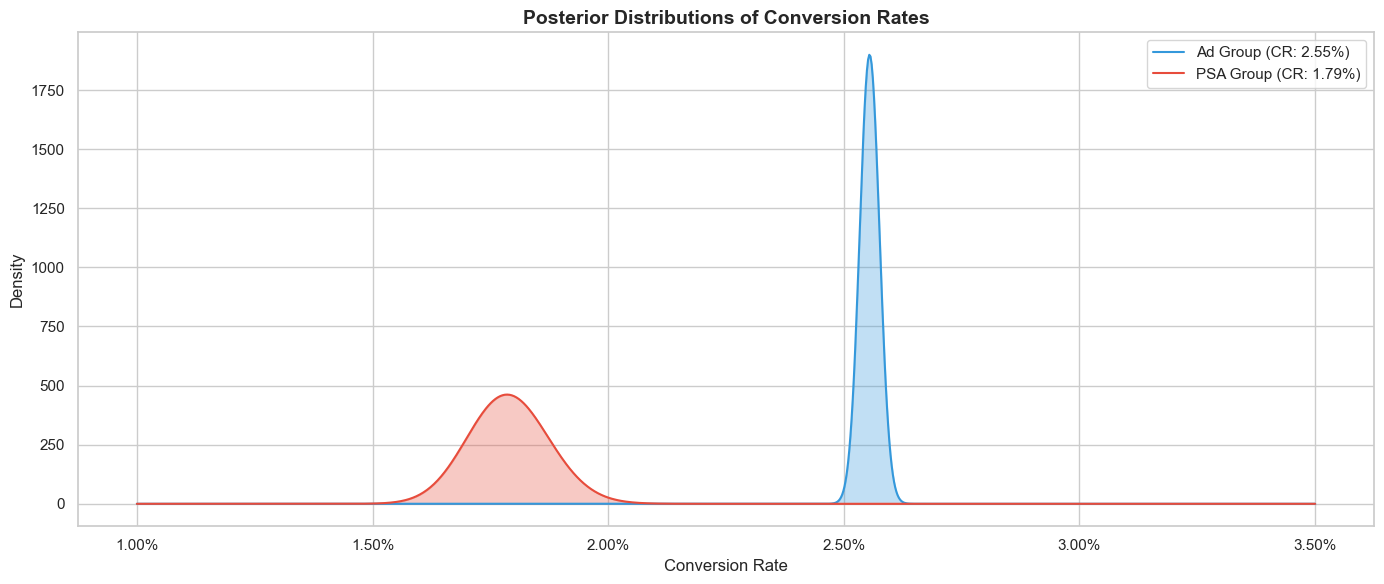

In [9]:
plt.figure(figsize=(14, 6))

x = np.linspace(0.010, 0.035, 1000)

# Plot Ad Posterior
plt.plot(x, posterior_ad.pdf(x), label=f'Ad Group (CR: {samples_ad.mean()*100:.2f}%)', color='#3498db')
plt.fill_between(x, posterior_ad.pdf(x), color='#3498db', alpha=0.3)

# Plot PSA Posterior
plt.plot(x, posterior_psa.pdf(x), label=f'PSA Group (CR: {samples_psa.mean()*100:.2f}%)', color='#e74c3c')
plt.fill_between(x, posterior_psa.pdf(x), color='#e74c3c', alpha=0.3)

plt.title('Posterior Distributions of Conversion Rates', fontsize=14, fontweight='bold')
plt.xlabel('Conversion Rate', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.tight_layout()
plt.show()

#### Conclusion & Recommendation
**The Experiment:** We tested a targeted Advertising Campaign against a baseline Public Service Announcement (PSA) to measure the impact on user conversion.

**The Results:**
1. **Statistical Significance:** The Ad campaign drove a statistically significant increase in conversions ($p < 0.001$).
2. **Confidence Interval:** We are 95% confident the true lift is between the CUPED-adjusted bounds — entirely above zero.
3. **Bayesian Probability:** There is a ~100% probability that the Ad variant outperforms the PSA variant.
4. **Lift:** The Ad group achieved a conversion rate of 2.55%, representing a meaningful relative lift over the PSA group's 1.78%.